In [1]:
import pandas as pd
import glob
import os

# Path to your folder
folder_path = '/Users/dougs/Annapurna Dropbox/Doug Sack/Interactive/IndieBI/MV_data'

# Get all CSV files
all_files = glob.glob(os.path.join(folder_path, "*.xlsx"))

# Read and combine files on specific columns
dfs = []
for file in all_files:
    df = pd.read_excel(file, usecols=['Product', 'Units (excl. refunds)'], skiprows=2)  # replace with your target columns
    df['source_file'] = os.path.splitext(os.path.basename(file))[0]  # Add file name without extension

    dfs.append(df)

In [2]:
# Combine all DataFrames
combined_df = pd.concat(dfs, ignore_index=True)

In [3]:
pivot_df = combined_df.pivot(index='Product', columns='source_file', values='Units (excl. refunds)')

In [4]:
df_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0)


In [5]:
apple = df_percent.dropna(subset="apple")
android = df_percent.dropna(subset="google")

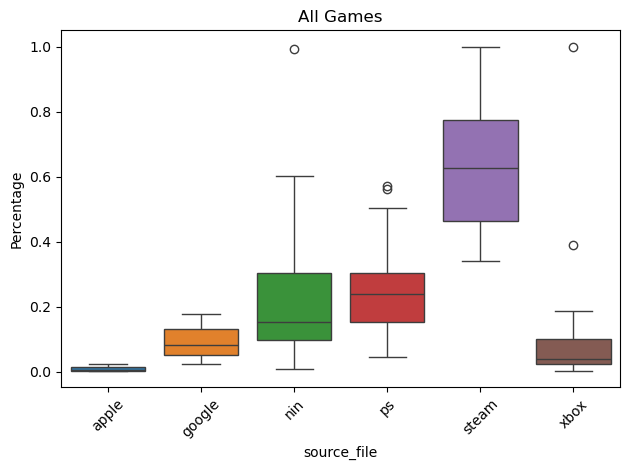

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_percent is in wide format (columns are categories)
sns.boxplot(data=df_percent)

plt.title("All Games")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

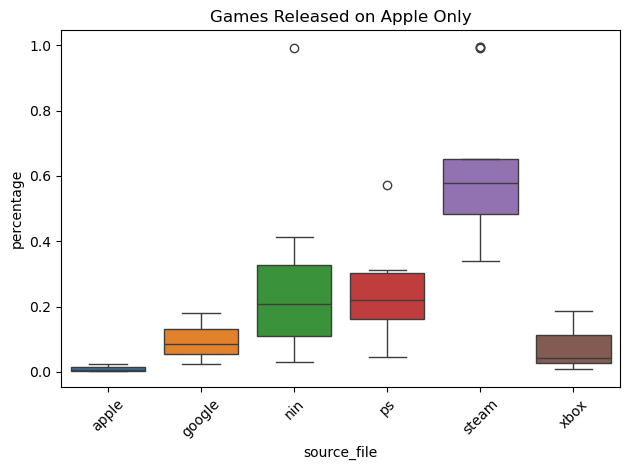

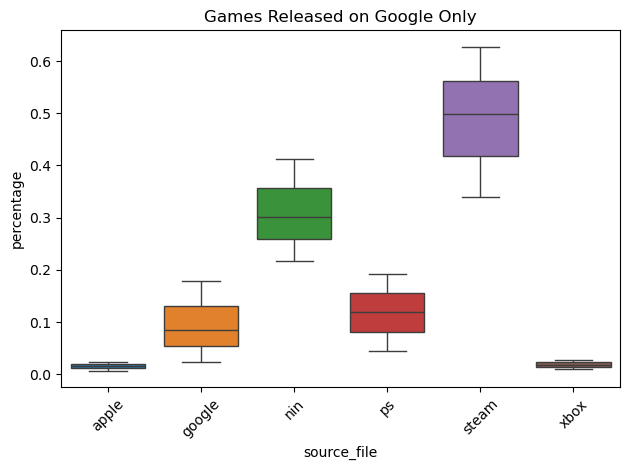

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_percent is in wide format (columns are categories)
sns.boxplot(data=apple)

plt.title("Games Released on Apple Only")
plt.ylabel("percentage")
plt.xticks(rotation=45)
#plt.yscale("log")
plt.tight_layout()
plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_percent is in wide format (columns are categories)
sns.boxplot(data=android)

plt.title("Games Released on Google Only")
plt.ylabel("percentage")
plt.xticks(rotation=45)
#plt.yscale("log")
plt.tight_layout()
plt.show()

In [8]:
df_percent.mean()

source_file
apple     0.009068
google    0.095254
nin       0.220663
ps        0.248326
steam     0.636274
xbox      0.099520
dtype: float64

In [9]:
apple.mean()

source_file
apple     0.009068
google    0.095254
nin       0.265558
ps        0.247499
steam     0.623813
xbox      0.072073
dtype: float64

In [10]:
df_percent.sort_values(by='google',ascending=False)

source_file,apple,google,nin,ps,steam,xbox
Product,,,,,,
Florence,0.022759,0.179083,0.300415,NaN,0.497743,NaN
Gorogoa,0.016418,0.083970,0.217942,0.044406,0.627899,0.009366
Donut County,0.005973,0.022708,0.411635,0.192693,0.339793,0.027198
A Memoir Blue,0.007187,NaN,0.093239,0.313248,0.399355,0.186971
Ashen,NaN,NaN,0.362435,0.236909,0.377060,0.023596
Ashen - Nightstorm Isle DLC,NaN,NaN,0.272548,0.251192,0.451466,0.024794
Ashen Definitive Edition,NaN,NaN,NaN,NaN,NaN,1.000000
Cocoon,NaN,NaN,0.154439,0.193539,0.633723,0.018299
Due Process,NaN,NaN,NaN,NaN,1.000000,NaN


In [30]:
pivot_df.sort_values(by='google',ascending=False)

source_file,apple,google,nin,ps,steam,xbox
Product,,,,,,
Florence,18236.0,143494.0,240714.0,NaN,398827.0,NaN
Gorogoa,18150.0,92831.0,240940.0,49092.0,694159.0,10354.0
Donut County,7266.0,27623.0,500726.0,234398.0,413335.0,33085.0
A Memoir Blue,263.0,NaN,3412.0,11463.0,14614.0,6842.0
Ashen,NaN,NaN,140807.0,92040.0,146489.0,9167.0
Ashen - Nightstorm Isle DLC,NaN,NaN,37737.0,34780.0,62510.0,3433.0
Ashen Definitive Edition,NaN,NaN,NaN,NaN,NaN,36258.0
Cocoon,NaN,NaN,43903.0,55018.0,180151.0,5202.0
Due Process,NaN,NaN,NaN,NaN,160067.0,NaN


In [12]:
df_percent.to_clipboard()

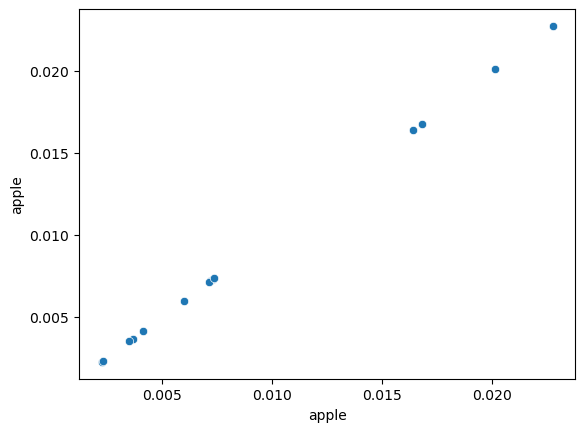

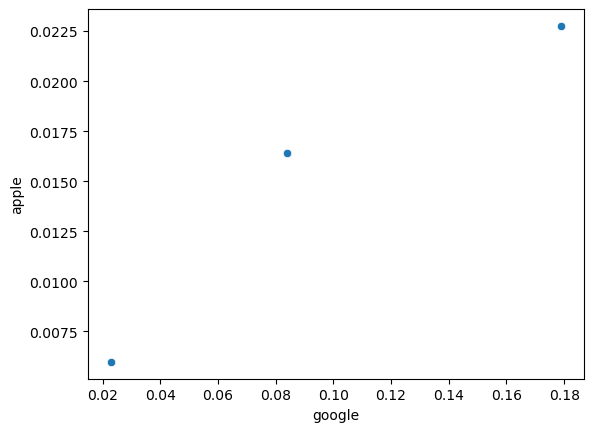

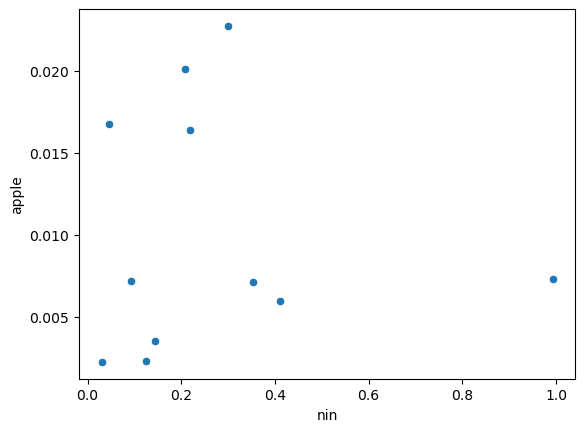

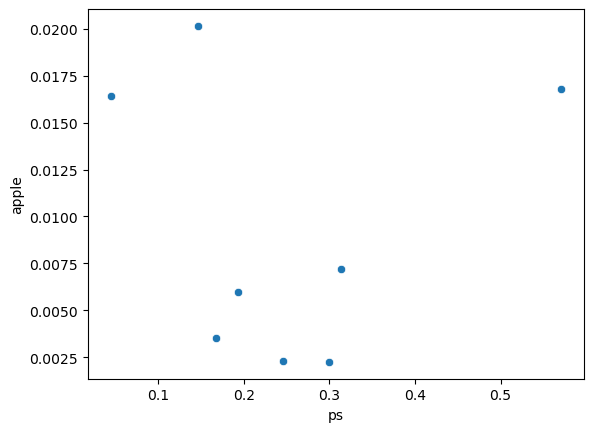

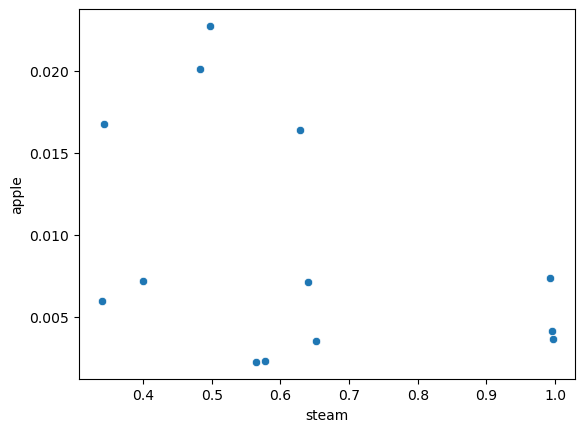

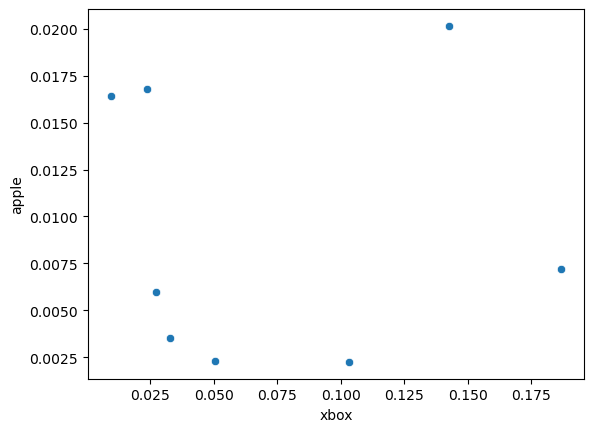

In [13]:
for col in df_percent.columns:
    sns.scatterplot(data=df_percent, x=col, y='apple')
    plt.show()

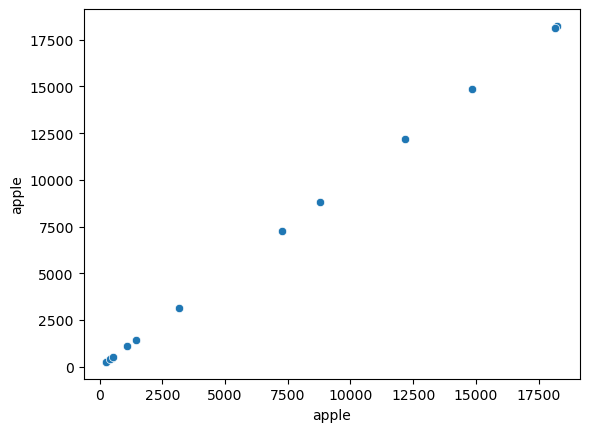

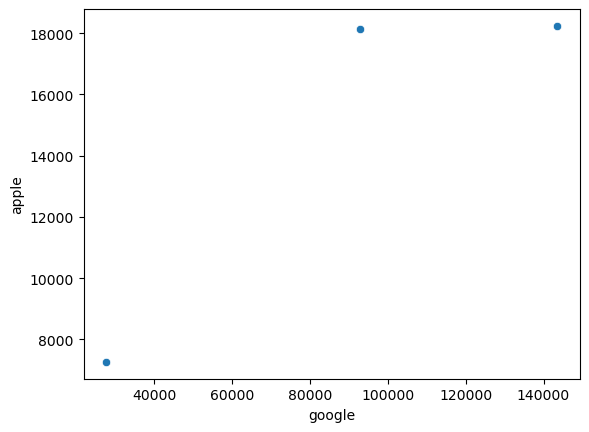

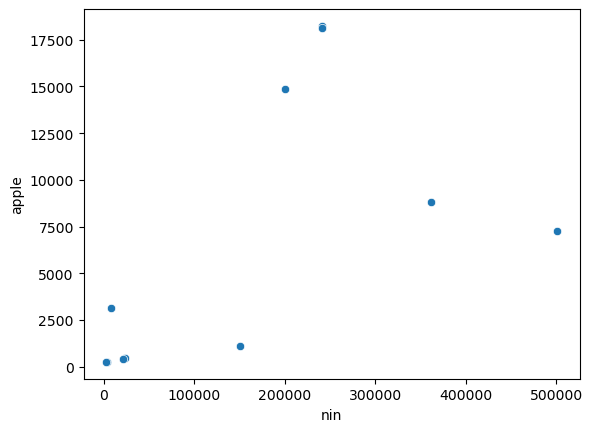

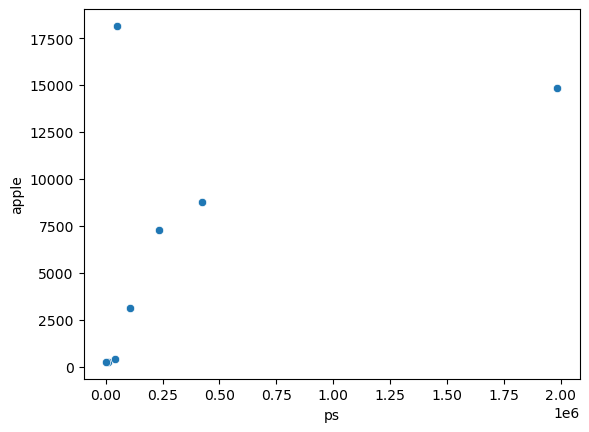

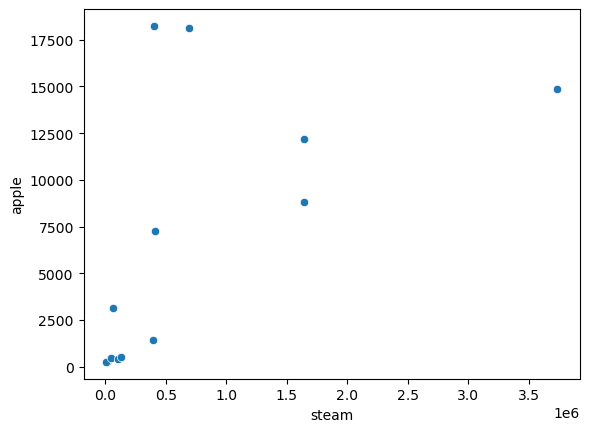

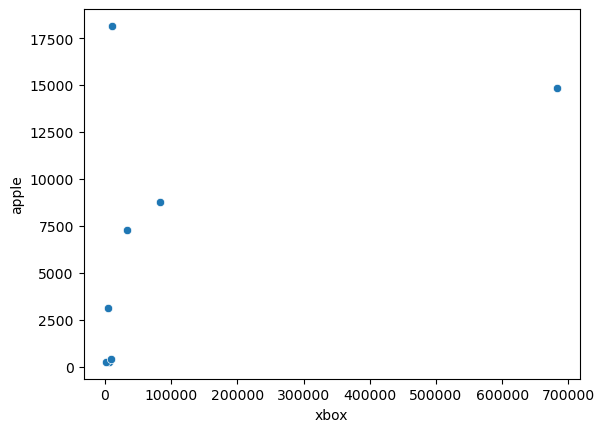

In [14]:
for col in pivot_df.columns:
    sns.scatterplot(data=pivot_df, x=col, y='apple')
    plt.show()